<a href="https://www.kaggle.com/code/ahmedfakhar123/ml-29-multiple-linear-regression?scriptVersionId=342155475" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

---
# 🤖 ML 29 — Multiple Linear Regression: Intuition & Code

### **Subtitle**
---

---

# 📚 What is Multiple Linear Regression?

**Multiple Linear Regression** is a supervised machine learning algorithm used to predict a **continuous target variable** using **multiple independent features**.

While Simple Linear Regression uses only one feature:

$y = \beta_0 + \beta_1x$

Multiple Linear Regression uses two or more features:

$y = \beta_0 + \beta_1x_1 + \beta_2x_2 + \cdots + \beta_nx_n$

Where:

* $(y)$ → predicted target
* $(\beta_0)$ → intercept
* $(\beta_1, \beta_2, ..., \beta_n)$ → coefficients
* $(x_1, x_2, ..., x_n)$ → input features

### 💡 Example

Suppose we want to predict a student's performance:

$Performance = \beta_0 +
\beta_1(Hours) +
\beta_2(PreviousScore) +
\beta_3(SleepHours) +
\beta_4(PracticePapers)$

The model learns the coefficients from the training data and uses them to make predictions.

---

# ⚙️ How Multiple Linear Regression Works

The overall process can be summarized as:

```text
             Dataset
                ↓
        Select Features & Target
                ↓
        Train-Test Split
                ↓
      Encode Categorical Data
                ↓
      Train Linear Regression
                ↓
          Make Predictions
                ↓
          Evaluate Model
                ↓
       Feature Selection
                ↓
      Compare Model Results
```

The model tries to find coefficients that minimize the difference between the **actual values** and **predicted values**.

A common loss function used for linear regression is **Mean Squared Error (MSE)**:

$MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y_i})^2$



---

# 📦 Import Required Libraries

We begin by importing the libraries required for data manipulation and analysis.




In [1]:
import numpy as np
import pandas as pd

---

# 📂 Loading the Dataset

For this notebook, we are using the **Student Performance** dataset.

The dataset contains information such as:

* Hours Studied
* Previous Scores
* Extracurricular Activities
* Sleep Hours
* Sample Question Papers Practiced
* Performance Index



In [2]:
df = pd.read_csv("/kaggle/input/datasets/nikhil7280/student-performance-multiple-linear-regression/Student_Performance.csv")
df

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,Yes,4,2,23.0
9996,7,64,Yes,8,5,58.0
9997,6,83,Yes,8,5,74.0
9998,9,97,Yes,7,0,95.0


---

# 🔎 Understanding the Dataset

Before building a model, it is important to understand the relationship between the numerical features and the target.

## 📊 Correlation Heatmap

Correlation measures the strength and direction of a linear relationship between numerical variables.



<Axes: >

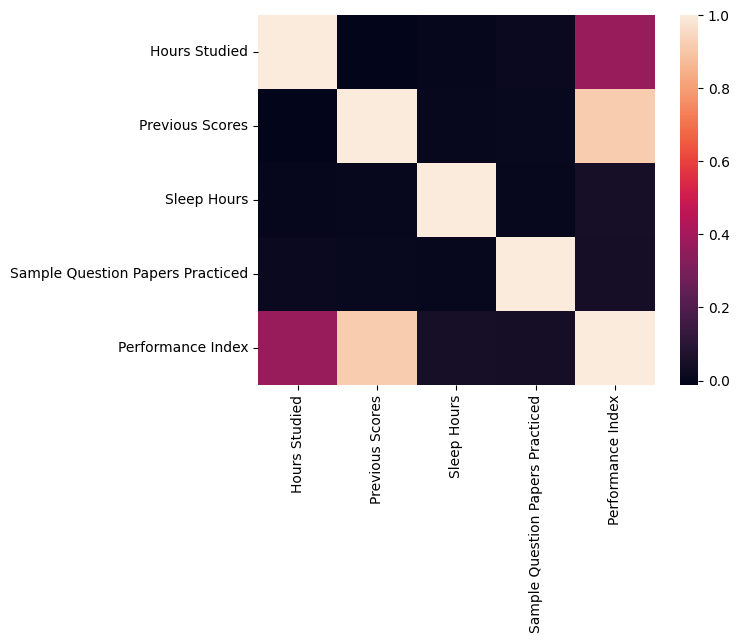

In [3]:
import seaborn as sns

sns.heatmap(df.corr(numeric_only=True))

---

# ✂️ Train-Test Split

Before training the model, we divide the dataset into:

* **Training set** → used to learn the model
* **Testing set** → used to evaluate the model on unseen data


In [4]:
from sklearn.model_selection import train_test_split

In [5]:
X = df.drop(columns=["Performance Index"])
y = df["Performance Index"]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

---

# 🔤 Encoding Categorical Features

Our dataset contains a categorical feature:

```text
Extracurricular Activities
```

It contains values such as:

```text
Yes
No
```

Machine learning algorithms generally require numerical input, so we need to convert these categories into numerical values.

We can use **One-Hot Encoding**.



In [6]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [7]:
transformer = ColumnTransformer([
    ('encoder', OneHotEncoder(sparse_output=False, drop="first"), [2])
], remainder="passthrough"
)


X_train_trf = transformer.fit_transform(X_train)
X_test_trf = transformer.transform(X_test)

In [8]:
X_train_trf

array([[ 0.,  5., 49.,  5.,  5.],
       [ 1.,  7., 88.,  4.,  9.],
       [ 1.,  3., 94.,  7.,  1.],
       ...,
       [ 0.,  9., 48.,  7.,  6.],
       [ 0.,  1., 47.,  9.,  0.],
       [ 0.,  2., 46.,  6.,  6.]])


---

# 🤖 Building the Multiple Linear Regression Model

Now that our data is numerical, we can train the model.


In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

model = LinearRegression()

model.fit(X_train_trf, y_train)

y_pred = model.predict(X_test_trf)

r2_score(y_test, y_pred)

0.9890550757439104

---

# 🎯 Feature Selection with SelectKBest

Now let's investigate whether we can build a simpler model using only the most useful features.

**SelectKBest** selects the top `k` features according to a statistical scoring function.

Here, we use the **Chi-Squared (`chi2`) test**:



In [10]:
from sklearn.feature_selection import SelectKBest, chi2

selector = SelectKBest(score_func=chi2, k=2)

X_train_new = selector.fit_transform(X_train_trf, y_train)
X_test_new = selector.transform(X_test_trf)

In [11]:
X_train_new

array([[ 5., 49.],
       [ 7., 88.],
       [ 3., 94.],
       ...,
       [ 9., 48.],
       [ 1., 47.],
       [ 2., 46.]])


---

# 🤖 Training the Model with Selected Features

Let's train another Multiple Linear Regression model using only these selected features.



In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

model1 = LinearRegression()

model1.fit(X_train_new, y_train)

y_pred1 = model1.predict(X_test_new)

r2_score(y_test, y_pred1)

0.9858714750293637


---

# 📊 Comparing Both Models

| Model             | Features Used |   R² Score |
| ----------------- | ------------: | ---------: |
| Original Model    |             5 | **0.9891** |
| SelectKBest Model |             2 | **0.9859** |

The original model performs slightly better because it has access to more information.

However, the feature-selected model achieves a very similar R² score while using only **2 features**.

This demonstrates an important idea:

> **More features do not always mean a dramatically better model.**

Feature selection can help create a simpler model while maintaining strong predictive performance.

---
# 📊 Visualizing Multiple Linear Regression

The graph below shows the regression surface learned by the model using the two selected features, along with the actual data points. This helps visualize how well the model fits the observed data.

In [13]:
# Create values for the two selected features
x = np.linspace(
    X_train_new[:, 0].min(),
    X_train_new[:, 0].max(),
    10
)

y = np.linspace(
    X_train_new[:, 1].min(),
    X_train_new[:, 1].max(),
    10
)

# Create a 2D grid
XGrid, YGrid = np.meshgrid(x, y)

# Convert grid into 100 rows with 2 features
grid_points = np.c_[
    XGrid.ravel(),
    YGrid.ravel()
]

# Predict Performance Index for every grid point
z_final = model1.predict(grid_points).reshape(10, 10)

# Final data for plotting
final = np.vstack((
    XGrid.ravel(),
    YGrid.ravel(),
    z_final.ravel()
)).T

In [14]:
import plotly.graph_objects as go

# Create grid for the two selected features
x = np.linspace(
    X_train_new[:, 0].min(),
    X_train_new[:, 0].max(),
    10
)

y = np.linspace(
    X_train_new[:, 1].min(),
    X_train_new[:, 1].max(),
    10
)

XGrid, YGrid = np.meshgrid(x, y)

# Create 100 grid points
grid_points = np.c_[
    XGrid.ravel(),
    YGrid.ravel()
]

# Predict values for the grid
z_final = model1.predict(grid_points).reshape(10, 10)

# Create 3D figure
fig = go.Figure()

# Regression surface
fig.add_trace(
    go.Surface(
        x=XGrid,
        y=YGrid,
        z=z_final,
        name="Regression Surface",
        opacity=0.7
    )
)

# Actual training data points
fig.add_trace(
    go.Scatter3d(
        x=X_train_new[:, 0],
        y=X_train_new[:, 1],
        z=y_train,
        mode="markers",
        name="Actual Data",
        marker=dict(
            size=4
        )
    )
)

fig.update_layout(
    title="Multiple Linear Regression — Actual Data vs Regression Surface",
    scene=dict(
        xaxis_title="Hours Studied",
        yaxis_title="Previous Scores",
        zaxis_title="Performance Index"
    )
)

fig.show()

---
# 🧮 Implementing Linear Regression from Scratch

To better understand how `LinearRegression` works internally, we can implement a simplified version ourselves using **NumPy**.

Instead of relying on Scikit-learn, we will calculate the model parameters using the **Ordinary Least Squares (OLS)** closed-form equation:

$\beta = (X^TX)^{-1}X^Ty$

Where:

* $(X)$ → feature matrix
* $(y)$ → target values
* $(\beta)$ → learned coefficients and intercept

## 🏗️ Building Our Own Linear Regression Class


In [15]:
class MyLinearRegression:

    def __init__(self):
        self.coef_ = None
        self.intercept_ = None

    def fit(self, X_train, y_train):

        # Add column of 1s for intercept
        X_train = np.insert(X_train, 0, 1, axis=1)

        # Calculate beta values
        betas = np.linalg.inv(
            X_train.T @ X_train
        ) @ X_train.T @ y_train

        # First beta is intercept
        self.intercept_ = betas[0]

        # Remaining betas are coefficients
        self.coef_ = betas[1:]

    def predict(self, X_test):

        return X_test @ self.coef_ + self.intercept_

In [16]:
my_model = MyLinearRegression()

## 🚀 Training Our Custom Model

We use the **same transformed training data** that was used by the Scikit-learn model.


In [17]:
my_model.fit(X_train_trf, y_train)

In [18]:
my_y_pred = my_model.predict(X_test_trf)

In [19]:
r2_score(y_test, my_y_pred)

0.9890550757439104

Our custom implementation produces essentially the **same R² score** as Scikit-learn's `LinearRegression`.

## 🧠 What Did We Learn?

This shows that the Scikit-learn model isn't a black box. At its core, Linear Regression is based on mathematical operations that can be implemented using NumPy.

Our workflow was:

```text
Feature Matrix (X)
       ↓
Add Intercept Column
       ↓
Calculate β = (XᵀX)⁻¹Xᵀy
       ↓
Separate Intercept & Coefficients
       ↓
Make Predictions
       ↓
Evaluate with R²
```

> **Note:** This implementation is primarily for learning. In real-world projects, Scikit-learn's implementation is preferred because it is more optimized and numerically robust.



---

# 🏁 Conclusion

In this notebook, we built a **Multiple Linear Regression** model to predict student performance using multiple features.

We first prepared the data by encoding the categorical feature and then trained a Scikit-learn `LinearRegression` model, achieving an impressive **R² score of 0.9891**.

We also explored **feature selection using `SelectKBest`**, reducing the model to two features. The reduced model achieved an R² score of **0.9859**, showing that we could remove several features while retaining most of the model's predictive performance.

Finally, we implemented **Linear Regression from scratch using NumPy** and the Ordinary Least Squares equation:

$\beta = (X^TX)^{-1}X^Ty$

Our custom implementation achieved the same **0.9891 R² score**, demonstrating that we understand not only how to use Linear Regression through Scikit-learn, but also the mathematical mechanism behind it. 🚀

---

# 🔜 What's Next?

In the next notebook, we'll go **under the hood of optimization** and build **Gradient Descent from scratch**.

[🤖 ML 30 — Gradient Descent from Scratch](https://www.kaggle.com/code/ahmedfakhar123/ml-30-gradient-descent-from-scratch)

We’ll explore how a machine learning model can iteratively update its parameters to minimize a **loss/cost function**, rather than directly calculating the optimal coefficients using the OLS closed-form equation.

The notebook will cover:

* 🧠 What is Gradient Descent?
* 📉 Cost/Loss Function
* 📐 Gradients and derivatives
* ⚙️ Learning rate
* 🔄 Parameter updates
* 🐍 Implementing Gradient Descent from scratch
* 🤖 Applying it to Linear Regression
* 📊 Visualizing the optimization process
* 🎬 Creating a **Gradient Descent animation** to see the algorithm converge step by step

> **From calculating the solution directly with OLS → to learning the solution iteratively with Gradient Descent.** 🚀
